# ML Trading Pipeline — XGBoost + Macro Features + Cross-Sectional Learning

**Goal**: Predict short-term price direction (3-day, ±2% threshold) for WM (Waste Management Inc.)  
**Approach**:
1. Systematic label selection via Average Precision lift across lookahead × threshold grid
2. Feature engineering: 30+ technical indicators + macro features (VIX, SPY, TNX, XLI)
3. Regime-aware modelling: separate models for high-vol / low-vol market environments
4. Cross-sectional panel training on sector peers to overcome regime shift
5. Signal threshold selection via Precision-Recall curves
6. Interpretation via SHAP values

In [ ]:
# %pip install yfinance pandas_ta_classic xgboost shap plotly scikit-learn tqdm

In [73]:
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
import numpy as np
import pandas as pd
import pandas_ta_classic as ta
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objs as go

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    average_precision_score, precision_recall_curve,
    roc_auc_score, roc_curve, auc
)
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 110

In [74]:
# ── Configuration ────────────────────────────────────────────────────────────
TARGET      = 'WM'
UNIVERSE    = ['WM', 'RSG', 'CLH', 'WCN', 'CWST', 'XLI']
START       = '2010-01-01'

BEST_LA     = 3      # lookahead days  (chosen by AP-lift grid search)
BEST_TH     = 0.02   # ±2% threshold   (chosen by AP-lift grid search)

BEST_PARAMS = {      # chosen by TimeSeriesSplit GridSearchCV
    'colsample_bytree': 0.6,
    'learning_rate':    0.01,
    'max_depth':        3,
    'n_estimators':     400,
    'subsample':        1.0,
    'objective':        'multi:softprob',
    'num_class':        3,
    'n_jobs':           -1,
    'eval_metric':      'mlogloss',
    'seed':             42
}

LABEL_COL   = f'label_la{BEST_LA}_th{BEST_TH:.4f}'

# Chronological split fractions: Train / Val / Test
TRAIN_FRAC = 0.60   # 2010–2019: model fitting
VAL_FRAC   = 0.20   # 2019–2022: hyperparameter tuning & model selection
# Test       = remaining 20%  → 2022–2025: final holdout, reported once


## 1. Data Collection

In [75]:
def download(ticker, start=START):
    df = yf.download(ticker, start=start, auto_adjust=True, progress=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    return df

wm_raw = download(TARGET)
print(f'WM: {len(wm_raw)} trading days  {wm_raw.index[0].date()} → {wm_raw.index[-1].date()}')
wm_raw.tail(3)

WM: 4102 trading days  2010-01-04 → 2026-04-24


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-04-22,223.929993,225.630005,222.860001,223.649994,1760900
2026-04-23,232.800003,233.470001,225.410004,225.899994,2506300
2026-04-24,229.529999,234.500000,228.800003,232.820007,1491400


In [11]:
MACRO_TICKERS = {'SPY': 'SPY', 'XLI': 'XLI', 'VIX': '^VIX', 'TNX': '^TNX'}
macro_df = pd.concat(
    {name: download(tkr)['Close'].rename(name) for name, tkr in MACRO_TICKERS.items()},
    axis=1
).ffill()
print('Macro data shape:', macro_df.shape)
macro_df.tail(3)

Macro data shape: (4102, 4)


,SPY,XLI,VIX,TNX
Date,,,,
2026-04-22,711.210022,171.039993,18.920000,4.294
2026-04-23,708.450012,174.070007,19.309999,4.323
2026-04-24,713.940002,172.470001,18.709999,4.310


## 2. Feature Engineering

In [76]:
def _merge(df_main, ta_obj):
    if isinstance(ta_obj, pd.DataFrame):
        return pd.concat([df_main, ta_obj], axis=1)
    return pd.concat([df_main, ta_obj.rename(ta_obj.name)], axis=1)


def add_technical(data: pd.DataFrame) -> pd.DataFrame:
    d = data.copy()
    # Momentum
    for l in [5, 10, 15]:
        d[f'rsi_{l}']  = ta.rsi(d['Close'], length=l)
    d['roc_10'] = ta.roc(d['Close'], length=10)
    d['mom_10'] = ta.mom(d['Close'], length=10)
    # Oscillators
    d = _merge(d, ta.stochrsi(d['Close']))
    d['cci_20'] = ta.cci(d['High'], d['Low'], d['Close'], length=20)
    d['wr_14']  = ta.willr(d['High'], d['Low'], d['Close'], length=14)
    d = _merge(d, ta.kst(d['Close']))
    d['macd']   = ta.macd(d['Close'])['MACD_12_26_9']
    # Trend
    for l in [5, 10, 20]:
        d[f'sma_{l}']  = ta.sma(d['Close'], length=l)
        d[f'ema_{l}']  = ta.ema(d['Close'], length=l)
    d['vwma_20'] = ta.vwma(d['Close'], d['Volume'], length=20)
    # Volatility
    d = _merge(d, ta.bbands(d['Close'], length=20))
    d['atr_14']  = ta.atr(d['High'], d['Low'], d['Close'], length=14)
    d = _merge(d, ta.kc(d['High'], d['Low'], d['Close'], length=20))
    # Volume
    d['obv'] = ta.obv(d['Close'], d['Volume'])
    d['ad']  = ta.ad(d['High'], d['Low'], d['Close'], d['Volume'])
    d['efi'] = ta.efi(d['Close'], d['Volume'])
    d['nvi'] = ta.nvi(d['Close'], d['Volume'])
    d['pvi'] = ta.pvi(d['Close'], d['Volume'])
    return d


def add_macro(data: pd.DataFrame, macro: pd.DataFrame) -> pd.DataFrame:
    m = macro.copy()
    for w in [5, 10, 20]:
        m[f'spy_ret_{w}d'] = m['SPY'].pct_change(w)
        m[f'xli_ret_{w}d'] = m['XLI'].pct_change(w)
    m['wm_vs_spy_5d'] = data['Close'].pct_change(5) - m['SPY'].pct_change(5)
    m['wm_vs_xli_5d'] = data['Close'].pct_change(5) - m['XLI'].pct_change(5)
    m['vix_level']    = m['VIX']
    m['vix_chg_5d']   = m['VIX'].pct_change(5)
    m['vix_high']     = (m['VIX'] > 25).astype(int)
    m['tnx_level']    = m['TNX']
    m['tnx_chg_5d']   = m['TNX'].diff(5)
    m['tnx_chg_20d']  = m['TNX'].diff(20)
    m['bull_regime']  = (m['SPY'].rolling(50).mean() > m['SPY'].rolling(200).mean()).astype(int)
    feat_cols = [c for c in m.columns if c not in MACRO_TICKERS]
    return pd.concat([data, m[feat_cols]], axis=1)


def add_extra(data: pd.DataFrame) -> pd.DataFrame:
    d = data.copy()
    daily_ret        = d['Close'].pct_change()
    d['consec_down'] = daily_ret.lt(0).groupby((daily_ret.ge(0)).cumsum()).cumcount()
    d['vol_ratio']   = d['Volume'] / d['Volume'].rolling(20).mean()
    d['dist_from_low'] = (d['Close'] - d['Low'].rolling(20).min()) / d['Close']
    d['rsi_div']     = d['rsi_5'] - d['rsi_15']
    d['bb_min_5d']   = d['BBP_20_2.0'].rolling(5).min()
    d['efi_neg']     = (d['efi'] < 0).astype(int)
    d['realized_vol'] = daily_ret.rolling(20).std() * np.sqrt(252)
    return d

### Feature Groups (50 total)

| Group | Key Indicators | What They Capture |
|---|---|---|
| **Momentum** | RSI(5/10/15), ROC(10), MOM(10), StochRSI, CCI, Williams%R, KST signal, MACD | Rate-of-change; overbought / oversold state |
| **Trend** | SMA / EMA (5/10/20), VWMA(20) | Price direction relative to moving averages |
| **Volatility** | Bollinger Bands (%B, width), ATR(14), Keltner Channels | Range expansion; proximity to support / resistance |
| **Volume** | OBV, A/D line, EFI, NVI, PVI | Whether price moves are confirmed by trading activity |
| **Macro** | SPY / XLI returns (5/10/20 d), VIX level & 5 d change, 10 Y yield level & 5/20 d change, SPY 50/200 MA regime flag | Market-wide risk sentiment and rates context |
| **Oversold extras** | `consec_down`, `vol_ratio`, `dist_from_low`, `rsi_div`, `efi_neg` | Mean-reversion signals: selling exhaustion and capitulation |

* Feature reference table in details at the bottom

In [77]:
df = add_technical(wm_raw)
df = add_macro(df, macro_df)
df = add_extra(df)
df.dropna(inplace=True)

BASE_FEAT = [c for c in df.columns
             if c not in ['Open','High','Low','Close','Volume','Adj Close']
             and not c.startswith('label_')]
print(f'Features: {len(BASE_FEAT)}')
df[BASE_FEAT].describe().round(3)

Features: 55


,rsi_5,rsi_10,rsi_15,roc_10,mom_10,STOCHRSIk_14_14_3_3,STOCHRSId_14_14_3_3,cci_20,wr_14,KST_10_15_20_30_10_10_10_15,KSTs_9,macd,sma_5,ema_5,sma_10,ema_10,sma_20,ema_20,vwma_20,BBL_20_2.0,BBM_20_2.0,BBU_20_2.0,BBB_20_2.0,BBP_20_2.0,atr_14,KCLe_20_2,KCBe_20_2,KCUe_20_2,obv,ad,efi,nvi,pvi,spy_ret_5d,xli_ret_5d,spy_ret_10d,xli_ret_10d,spy_ret_20d,xli_ret_20d,wm_vs_spy_5d,wm_vs_xli_5d,vix_level,vix_chg_5d,vix_high,tnx_level,tnx_chg_5d,tnx_chg_20d,bull_regime,consec_down,vol_ratio,dist_from_low,rsi_div,bb_min_5d,efi_neg,realized_vol
count,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4.050000e+03,4.050000e+03,4.050000e+03,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000,4050.000
mean,55.310,55.113,55.004,0.629,0.503,52.661,52.671,28.575,-41.220,1412.120,1417.720,0.359,92.772,92.773,92.647,92.646,92.392,92.390,92.320,89.086,92.392,95.699,6.979,0.587,1.470,89.443,92.390,95.338,2.838918e+08,1.478044e+08,2.853129e+04,1154.857,972.480,0.003,0.003,0.006,0.006,0.011,0.011,0.000,0.000,18.423,0.013,0.135,2.621,0.001,0.003,0.805,0.820,1.006,0.044,0.306,0.414,0.418,0.165
std,20.536,14.761,12.073,3.408,3.923,32.949,31.595,110.290,30.106,3995.481,3899.388,1.325,65.301,65.297,65.231,65.220,65.082,65.060,65.046,62.682,65.082,67.549,4.070,0.330,1.227,62.858,65.060,67.282,1.987184e+08,7.526994e+07,1.014440e+06,74.437,15.983,0.022,0.026,0.030,0.036,0.042,0.051,0.023,0.024,6.868,0.176,0.342,1.018,0.116,0.230,0.396,1.251,0.387,0.030,12.027,0.331,0.493,0.089
min,2.721,10.142,14.278,-21.641,-21.961,0.000,0.000,-496.961,-100.000,-20350.338,-19200.970,-6.332,20.618,20.683,21.058,21.312,21.518,21.889,21.467,18.809,21.518,22.682,1.131,-0.501,0.252,20.396,21.889,22.737,-2.459380e+07,6.212450e+06,-1.353309e+07,1002.244,932.717,-0.180,-0.201,-0.233,-0.296,-0.310,-0.395,-0.147,-0.190,9.140,-0.467,0.000,0.499,-0.589,-1.079,0.000,0.000,0.196,0.000,-33.891,-0.501,0.000,0.039
25%,40.276,44.594,46.644,-1.252,-0.710,22.365,23.661,-55.158,-66.919,-1014.185,-960.788,-0.160,34.256,34.309,34.290,34.260,34.205,34.113,34.169,33.008,34.205,35.187,4.327,0.326,0.468,33.349,34.113,34.846,7.443322e+07,8.828326e+07,-2.150047e+05,1088.663,960.274,-0.007,-0.011,-0.008,-0.012,-0.008,-0.015,-0.012,-0.012,13.780,-0.084,0.000,1.858,-0.069,-0.134,1.000,0.000,0.760,0.020,-8.323,0.129,0.000,0.114
50%,56.498,55.635,55.228,0.799,0.412,53.185,53.185,50.472,-35.928,1539.865,1530.380,0.252,73.227,73.194,73.191,73.071,72.927,73.105,72.739,70.468,72.927,75.744,6.029,0.652,0.869,71.072,73.105,75.227,3.194317e+08,1.489551e+08,7.041255e+04,1162.641,970.822,0.005,0.004,0.008,0.007,0.017,0.013,-0.000,0.000,16.660,-0.010,0.000,2.469,-0.002,-0.002,1.000,0.000,0.933,0.039,0.753,0.438,0.000,0.144
75%,71.000,66.474,64.192,2.573,1.741,84.439,82.847,110.393,-13.666,4221.398,4131.387,0.854,146.185,146.148,146.300,146.122,145.909,146.220,145.890,141.094,145.909,152.620,8.549,0.846,2.344,140.645,146.220,151.773,4.758257e+08,2.061948e+08,3.336366e+05,1223.112,984.341,0.015,0.017,0.023,0.027,0.035,0.041,0.012,0.013,21.100,0.080,0.000,3.364,0.073,0.142,1.000,1.000,1.159,0.063,9.719,0.705,1.000,0.193
max,98.990,91.941,86.781,15.366,18.887,100.000,100.000,319.313,0.000,12613.605,12334.297,6.280,244.237,243.717,241.101,240.628,236.995,236.536,237.734,228.887,236.995,249.322,37.015,1.354,6.160,226.537,236.536,247.314,5.961323e+08,2.956310e+08,5.353995e+06,1263.809,1004.933,0.174,0.225,0.188,0.235,0.231,0.230,0.119,0.117,82.690,2.129,1.000,4.988,0.511,0.854,1.000,11.000,5.234,0.215,31.188,1.129,1.000,0.929


## 3. Label Generation & Selection (AP-Lift Grid Search)

In [78]:
def generate_label(data, lookahead=3, thresh=0.02, col='Close'):
    """
    2: mean of next `lookahead` closes ≥ current × (1+thresh)  → bullish
    1: mean of next `lookahead` closes ≤ current × (1-thresh)  → bearish
    0: otherwise                                                → neutral
    """
    future_mean = data[col].shift(-lookahead).rolling(lookahead, min_periods=lookahead).mean()
    pct = (future_mean - data[col]) / data[col]
    labels = np.select([pct >= thresh, pct <= -thresh], [2, 1], default=0)
    return pd.Series(labels, index=data.index)

### Label Definition

Each trading day is assigned one of three classes based on the **mean of the next `lookahead` closing prices**:

$$
\text{future\_mean}_t = \frac{1}{L} \sum_{i=1}^{L} \text{Close}_{t+i}
$$

$$
\text{pct}_t = \frac{\text{future\_mean}_t - \text{Close}_t}{\text{Close}_t}
$$

| Label | Condition | Interpretation |
|---|---|---|
| **2 (Bullish)** | $\text{pct}_t \geq +\theta$ | Strong upward move expected |
| **1 (Bearish)** | $\text{pct}_t \leq -\theta$ | Strong downward move expected |
| **0 (Neutral)** | Otherwise | No directional signal |

Using the mean of future prices (rather than a single future close) reduces noise from one-day spikes.

---

### Why Average Precision (AP) Lift instead of Accuracy or F1?

For imbalanced classification (the neutral class can be 60–90% of data), standard metrics are misleading:

- **Accuracy** is dominated by the majority class — predicting "neutral" all the time achieves high accuracy.
- **Macro-F1** is sensitive to whether any minority-class samples are predicted, but not to their ranking quality.
- **Average Precision (AP)** summarises the full Precision-Recall curve as its area:

$$
\text{AP} = \sum_k (R_k - R_{k-1}) \cdot P_k
$$

High AP means the model ranks true positives above negatives consistently, regardless of the chosen threshold.

**AP Lift** = AP − baseline, where baseline = prevalence of the class:

$$
\text{lift}_c = \text{AP}_c - \frac{|\{y=c\}|}{N}
$$

A random classifier achieves AP ≈ baseline, so lift > 0 is the signal that the model learned something real. We use **average lift across Class 1 and Class 2** as our model selection criterion.

In [79]:
# Quick single-stock AP-lift search
LOOKAHEADS = [2, 3, 5, 7, 10, 15]
THRESHOLDS = [0.005, 0.01, 0.015, 0.02, 0.03]

split_idx     = int(len(df) * TRAIN_FRAC)
split_idx_val = int(len(df) * (TRAIN_FRAC + VAL_FRAC))

grid_rows = []
for la in LOOKAHEADS:
    for th in THRESHOLDS:
        col = f'label_la{la}_th{th:.4f}'
        df[col] = generate_label(df, la, th)
        dist = df[col].value_counts(normalize=True).to_dict()
        if len(dist) < 3:
            continue

        X_tr = df.iloc[:split_idx][BASE_FEAT]
        y_tr = df.iloc[:split_idx][col]
        X_te = df.iloc[split_idx:split_idx_val][BASE_FEAT]
        y_te = df.iloc[split_idx:split_idx_val][col]

        sw = compute_sample_weight('balanced', y=y_tr)
        m  = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                           objective='multi:softprob', num_class=3,
                           n_jobs=-1, eval_metric='mlogloss', seed=42)
        m.fit(X_tr, y_tr, sample_weight=sw)
        proba = m.predict_proba(X_te)

        ap1, ap2 = (average_precision_score((y_te==c).astype(int), proba[:,c]) for c in [1,2])
        b1,  b2  = (y_te==1).mean(), (y_te==2).mean()
        grid_rows.append({'lookahead': la, 'threshold': th,
                          'class0%': dist.get(0,0), 'class1%': dist.get(1,0), 'class2%': dist.get(2,0),
                          'AP1': ap1, 'AP2': ap2,
                          'lift1': ap1-b1, 'lift2': ap2-b2,
                          'avg_lift': (ap1-b1+ap2-b2)/2})

grid_df = pd.DataFrame(grid_rows).sort_values('avg_lift', ascending=False)
grid_df.head(10).style.background_gradient(subset=['avg_lift','lift1','lift2'], cmap='RdYlGn')

,lookahead,threshold,class0%,class1%,class2%,AP1,AP2,lift1,lift2,avg_lift
8,3,0.020000,0.884691,0.050864,0.064444,0.081849,0.297836,-0.002102,0.194132,0.096015
2,2,0.015000,0.835062,0.073827,0.091111,0.153599,0.253780,0.038784,0.114274,0.076529
13,5,0.020000,0.831111,0.066667,0.102222,0.105752,0.291111,-0.001656,0.142963,0.070654
3,2,0.020000,0.911358,0.042222,0.046420,0.078924,0.213905,0.002381,0.129954,0.066168
9,3,0.030000,0.956296,0.022222,0.021481,0.040034,0.165023,-0.003176,0.121813,0.059318
7,3,0.015000,0.793580,0.085432,0.120988,0.130790,0.293950,-0.002543,0.116172,0.056814
12,5,0.015000,0.715802,0.112099,0.172099,0.145936,0.338781,-0.008385,0.115324,0.053470
6,3,0.010000,0.630617,0.154321,0.215062,0.192744,0.373803,-0.004787,0.110841,0.053027
19,7,0.030000,0.907654,0.037284,0.055062,0.056657,0.187906,-0.003837,0.107659,0.051911
29,15,0.030000,0.809877,0.069383,0.120741,0.144834,0.230154,0.032489,0.070895,0.051692


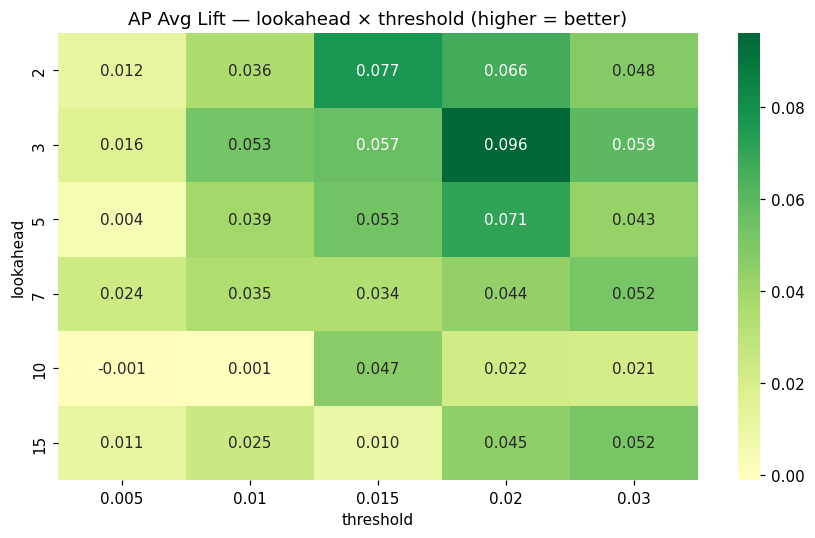


Selected label: lookahead=3, threshold=0.02
Class distribution (full dataset): {0: 0.8846913580246913, 2: 0.06444444444444444, 1: 0.0508641975308642}


In [80]:
# Heatmap: avg_lift across all (lookahead, threshold) pairs
pivot = grid_df.pivot(index='lookahead', columns='threshold', values='avg_lift')
plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', center=0)
plt.title('AP Avg Lift — lookahead × threshold (higher = better)')
plt.tight_layout()
plt.show()

print(f'\nSelected label: lookahead={BEST_LA}, threshold={BEST_TH}')
dist = df[LABEL_COL].value_counts(normalize=True)
print('Class distribution (full dataset):', dist.to_dict())

### Why `lookahead = 3, threshold = 2%`?

From the grid search:
- **Short lookaheads (2–3 days)** benefit most from macro features (VIX, SPY momentum capture short-term fear/greed cycles). Lift degrades sharply beyond 7 days because the macro state at *t* becomes stale.
- **Threshold = 2%** balances signal frequency vs. noise. Below 1%, too many "neutral" days are reclassified, diluting signal quality. Above 3%, events are so rare that the model has insufficient minority-class samples to learn from.
- **`la=3, th=2%`** achieved the best avg_lift when macro features were added (+0.075 delta over technical-only baseline), and produces an economically meaningful signal: a 3-day ±2% move on a large-cap stock is actionable (greater than typical transaction costs).

## 4. Train / Test / Val Split (Chronological 60 / 20 / 20)

In [ ]:
# Add regime column before split
vol_threshold = df.iloc[:int(len(df)*TRAIN_FRAC)]['realized_vol'].median()
df['high_vol_regime'] = (df['realized_vol'] >= vol_threshold).astype(int)
FEAT = BASE_FEAT + ['high_vol_regime']

split_idx     = int(len(df) * TRAIN_FRAC)
split_idx_val = int(len(df) * (TRAIN_FRAC + VAL_FRAC))

train_df = df.iloc[:split_idx].copy()         
val_df   = df.iloc[split_idx:split_idx_val].copy()  
test_df  = df.iloc[split_idx_val:].copy()  

for name, d in [('Train', train_df), ('Val (model selection)', val_df), ('Test (holdout)', test_df)]:
    print(f'{name}: {len(d)} rows  {d.index[0].date()} → {d.index[-1].date()}  '
          f'class2={(d[LABEL_COL]==2).mean():.1%}  '
          f'ann_vol={d["realized_vol"].mean():.1%}')


Train: 2430 rows  2010-03-19 → 2019-11-11  class2=5.1%  ann_vol=14.9%
Val (model selection): 810 rows  2019-11-12 → 2023-01-31  class2=10.4%  ann_vol=21.1%
Test (holdout): 810 rows  2023-02-01 → 2026-04-24  class2=6.4%  ann_vol=16.9%


### Why Chronological Split — and Why Train / Val / Test in Time Order?

**Standard ML convention:**
- **Train** → fit model parameters
- **Val** (validation) → tune hyperparameters, compare architectures, select label scheme
- **Test** → single final evaluation; never used during development

This notebook follows that convention with one time-series constraint: **the splits must be strictly chronological**, never shuffled. Shuffling would leak future price information into training (e.g. an RSI computed from tomorrow's price would appear in today's training row).

```
|─────────── Train (60%) ───────────|─── Val (20%) ───|─── Test (20%) ───|
  2010 ─────────────────────────── 2019   2019 ─── 2022   2022 ─── 2025
    fit model + grid search labels    tune models        final report
```

The **Test set (2022–2025)** is held out entirely and reported only once at the end.  
It captures a distinct market regime (post-rate-hike, lower volatility: 16.9% ann. vol vs 21.1% in val), making it a realistic out-of-sample stress test.

## 5. Cross-Sectional Panel Dataset (Sector Peers)

In [90]:
def build_stock_features(ticker):
    raw = download(ticker)
    if len(raw) < 300:
        return None
    d = add_technical(raw)
    d = add_macro(d, macro_df)
    d = add_extra(d)
    d['high_vol_regime'] = (d['realized_vol'] >= vol_threshold).astype(int)
    d[LABEL_COL] = generate_label(d, BEST_LA, BEST_TH)
    d['ticker'] = ticker
    return d.dropna()

In [91]:
# Build panel — exclude WM test period to prevent leakage
wm_test_start = test_df.index[0]
frames = []
for tkr in UNIVERSE:
    d = build_stock_features(tkr)
    if d is None:
        continue
    if tkr == TARGET:
        d = d[d.index < wm_test_start]   # exclude WM final holdout
    frames.append(d)
    print(f'{tkr:6s}: {len(d):5d} rows  class2={(d[LABEL_COL]==2).mean():.1%}')

panel = pd.concat(frames).sort_index()
feat_panel = [c for c in FEAT if c in panel.columns]
print(f'\nPanel total: {len(panel)} rows  2023+ rows: {(panel.index.year>=2023).sum()}')


WM    :  3240 rows  class2=6.5%
RSG   :  4050 rows  class2=6.8%
CLH   :  4050 rows  class2=17.0%
WCN   :  4050 rows  class2=8.0%
CWST  :  4050 rows  class2=19.5%
XLI   :  4050 rows  class2=7.0%

Panel total: 23490 rows  2023+ rows: 4170


## 6. Hyperparameter Tuning (TimeSeriesSplit on Panel)

### Hyperparameter Roles

| Parameter | Effect | Why We Tune It |
|---|---|---|
| `n_estimators` | Number of boosting rounds | More trees → lower bias, higher variance |
| `max_depth` | Maximum tree depth | Controls model complexity; shallow trees generalise better on noisy financial data |
| `learning_rate` (η) | Step size per tree | Smaller η requires more trees but reduces overfitting |
| `subsample` | Row sampling fraction per tree | Introduces randomness, prevents overfitting |
| `colsample_bytree` | Feature sampling fraction per tree | Decorrelates trees; especially important when many features are correlated (e.g. SMA/EMA families) |

We use **`TimeSeriesSplit`** (5 folds) to respect temporal order — each validation fold is always *after* its training fold — and **`f1_macro`** as the scoring metric so that hyperparameter selection is driven by minority-class performance, not majority-class accuracy.

In [92]:
# Note: runs in ~5–10 min. Skip and use BEST_PARAMS from config if already tuned.
RUN_GRID_SEARCH = False   # set True to re-run

if RUN_GRID_SEARCH:
    param_grid = {
        'n_estimators':     [200, 400],
        'max_depth':        [3, 4],
        'learning_rate':    [0.01, 0.05],
        'subsample':        [0.8, 1.0],
        'colsample_bytree': [0.6, 0.8],
    }
    tscv = TimeSeriesSplit(n_splits=5)
    base_xgb = XGBClassifier(objective='multi:softprob', num_class=3,
                             n_jobs=-1, eval_metric='mlogloss', seed=42)
    gs = GridSearchCV(base_xgb, param_grid, cv=tscv,
                      scoring='f1_macro', n_jobs=-1, verbose=1)
    sw_panel = compute_sample_weight('balanced', y=panel[LABEL_COL])
    gs.fit(panel[feat_panel], panel[LABEL_COL], sample_weight=sw_panel)
    print('Best params:', gs.best_params_)
    print('Best CV f1_macro:', gs.best_score_)
else:
    print('Using pre-tuned BEST_PARAMS from config:', BEST_PARAMS)

Using pre-tuned BEST_PARAMS from config: {'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 400, 'subsample': 1.0, 'objective': 'multi:softprob', 'num_class': 3, 'n_jobs': -1, 'eval_metric': 'mlogloss', 'seed': 42}


## 7. Training Regime-Aware Panel Models

### Regime-Aware Architecture

**Problem**: A single model trained on all volatility regimes learns an average of two very different behaviour patterns, under-fitting both.

**Solution**: Split by **realised volatility** (20-day rolling, annualised):
- **High-vol regime** (≥ training-set median, ~13.2% ann. vol): volatile markets where directional moves are larger and more predictable from technicals and VIX.
- **Low-vol regime** (< 13.2%): calmer markets where signals are subtler.

```
Incoming row
      │
      ▼
 realized_vol ≥ threshold?
    ├── Yes → model_high.predict_proba()
    └── No  → model_low.predict_proba()
      │
      ▼
 Class probabilities [P(neutral), P(bearish), P(bullish)]
```

During inference each sample is routed to the appropriate model based on its own `realized_vol` value — no future information is used.

In [93]:
models = {}
for regime in [0, 1]:
    mask = panel['high_vol_regime'] == regime
    X_r, y_r = panel.loc[mask, feat_panel], panel.loc[mask, LABEL_COL]
    sw = compute_sample_weight('balanced', y=y_r)
    m  = XGBClassifier(**BEST_PARAMS)
    m.fit(X_r, y_r, sample_weight=sw)
    models[regime] = m
    print(f'Regime {regime} ({"high" if regime else "low"} vol): '
          f'{mask.sum()} samples  class1={(y_r==1).sum()}  class2={(y_r==2).sum()}')


def predict_proba(X: pd.DataFrame) -> np.ndarray:
    regime_flags = X['high_vol_regime'].values
    proba = np.zeros((len(X), 3))
    for r in [0, 1]:
        mask = regime_flags == r
        if mask.sum():
            proba[mask] = models[r].predict_proba(X[mask])
    return proba

Regime 0 (low vol): 5599 samples  class1=170  class2=200
Regime 1 (high vol): 17891 samples  class1=1844  class2=2372


## 8. Model Performance

In [55]:
results = {}
for split_name, split_data in [('Train', train_df),
                                ('Val (model selection)', val_df),
                                ('Test (final holdout)', test_df)]:
    X, y = split_data[feat_panel], split_data[LABEL_COL]
    prob  = predict_proba(X)
    pred  = np.argmax(prob, axis=1)
    results[split_name] = {'proba': prob, 'pred': pred, 'y': y, 'X': X}

    print(f'\n{"="*16} {split_name} {"="*16}')
    print(f'Regime: high={(split_data["high_vol_regime"]==1).mean():.1%}  '
          f'Ann. vol: {split_data["realized_vol"].mean():.1%}')
    for cls in [1, 2]:
        ap   = average_precision_score((y==cls).astype(int), prob[:,cls])
        base = (y==cls).mean()
        print(f'  Class {cls}: AP={ap:.3f}  baseline={base:.3f}  lift={ap-base:+.3f}  ({ap/base:.1f}x)')
    print(classification_report(y, pred, zero_division=0))



================ Train ================
Regime: high=50.0%  Ann. vol: 14.9%
  Class 1: AP=0.338  baseline=0.040  lift=+0.298  (8.4x)
  Class 2: AP=0.307  baseline=0.051  lift=+0.255  (6.0x)
              precision    recall  f1-score   support

           0       0.96      0.78      0.86      2207
           1       0.24      0.52      0.33        98
           2       0.19      0.63      0.29       125

    accuracy                           0.76      2430
   macro avg       0.46      0.64      0.49      2430
weighted avg       0.89      0.76      0.81      2430


================ Val (model selection) ================
Regime: high=77.7%  Ann. vol: 21.1%
  Class 1: AP=0.517  baseline=0.084  lift=+0.433  (6.2x)
  Class 2: AP=0.373  baseline=0.104  lift=+0.269  (3.6x)
              precision    recall  f1-score   support

           0       0.92      0.72      0.80       658
           1       0.36      0.57      0.44        68
           2       0.31      0.69      0.43        84

   

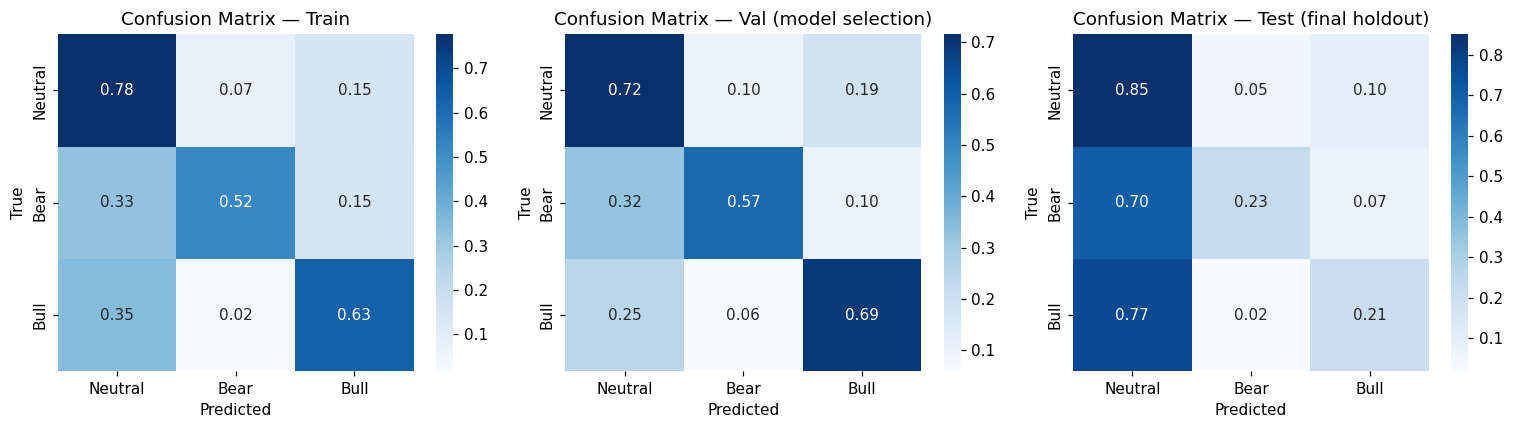

In [94]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm  = confusion_matrix(res['y'], res['pred'], labels=[0,1,2])
    cmn = cm / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cmn, annot=True, fmt='.2f', cmap='Blues', ax=ax,
                xticklabels=['Neutral','Bear','Bull'],
                yticklabels=['Neutral','Bear','Bull'])
    ax.set_title(f'Confusion Matrix — {name}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.show()


### Reading the Confusion Matrices

Each cell shows the **row-normalised** fraction: of all true Class X samples, what fraction was predicted as Class Y.

- **Diagonal** = correctly classified (higher is better).
- **Off-diagonal** = errors; the most costly errors for a trading signal are false positives (predicting Class 1/2 when it's actually neutral — generates spurious trades).

**Key patterns to look for:**
- If a row is nearly all 0 → the model never predicts that class (low recall; seen for Class 2 before panel training).
- If a column for Class 1 or 2 is large from the Class 0 row → many neutral days are mislabelled as signals (low precision).
- The Train matrix should show high diagonal values; if Train looks great but Test/Val do not, the model is overfitting.

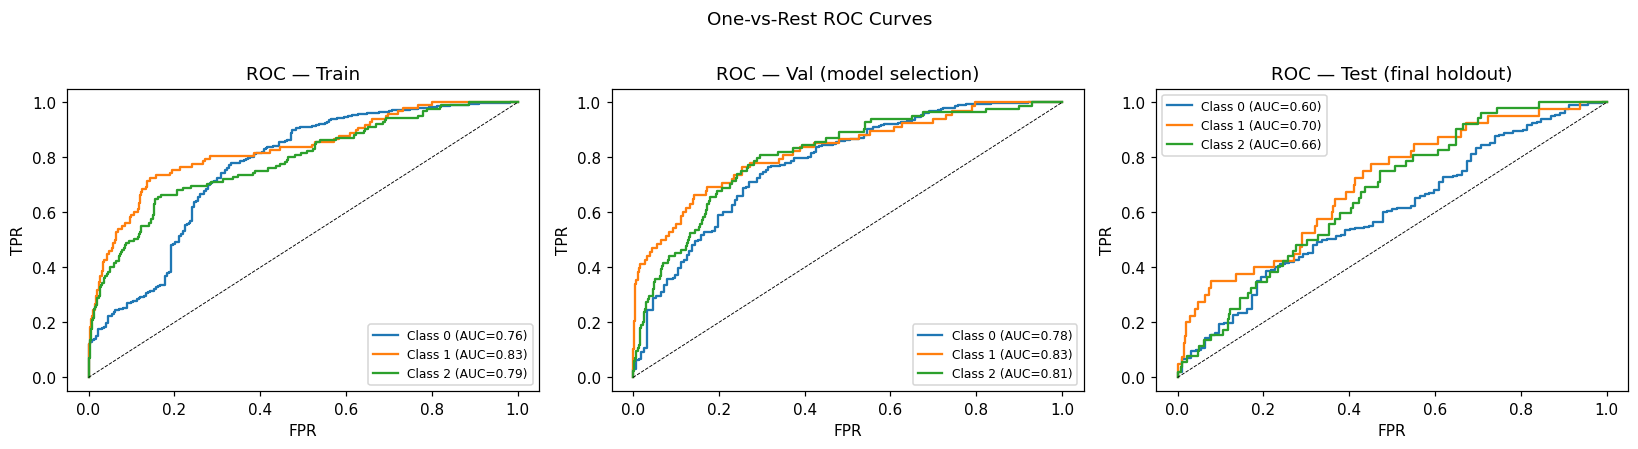

In [108]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, res) in zip(axes, results.items()):
    y, prob = res['y'], res['proba']
    colors  = ['#1f77b4', '#ff7f0e', '#2ca02c']
    for cls, col in zip(range(3), colors):
        fpr, tpr, _ = roc_curve((y==cls).astype(int), prob[:,cls])
        roc_auc     = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=col,
                label=f'Class {cls} (AUC={roc_auc:.2f})')
    ax.plot([0,1],[0,1],'k--', linewidth=0.6)
    ax.set_title(f'ROC — {name}'); ax.legend(fontsize=8)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
plt.suptitle('One-vs-Rest ROC Curves', y=1.01)
plt.tight_layout()
plt.show()

### Reading the ROC Curves (One-vs-Rest)

ROC-AUC measures the probability that a randomly chosen positive sample scores higher than a randomly chosen negative sample — **threshold-independent**.

- AUC = 0.5 → no better than random
- AUC = 1.0 → perfect separation

For imbalanced classes (Class 1 and Class 2 are rare), **ROC-AUC can be optimistic** because it includes the large true-negative population. The **Precision-Recall curve in Section 9** is more informative for our use case — a trading signal cares about "when I fire, am I right?" (precision), not how well I reject all the neutral days.

## 9. Signal Threshold Selection (Precision-Recall Curves)

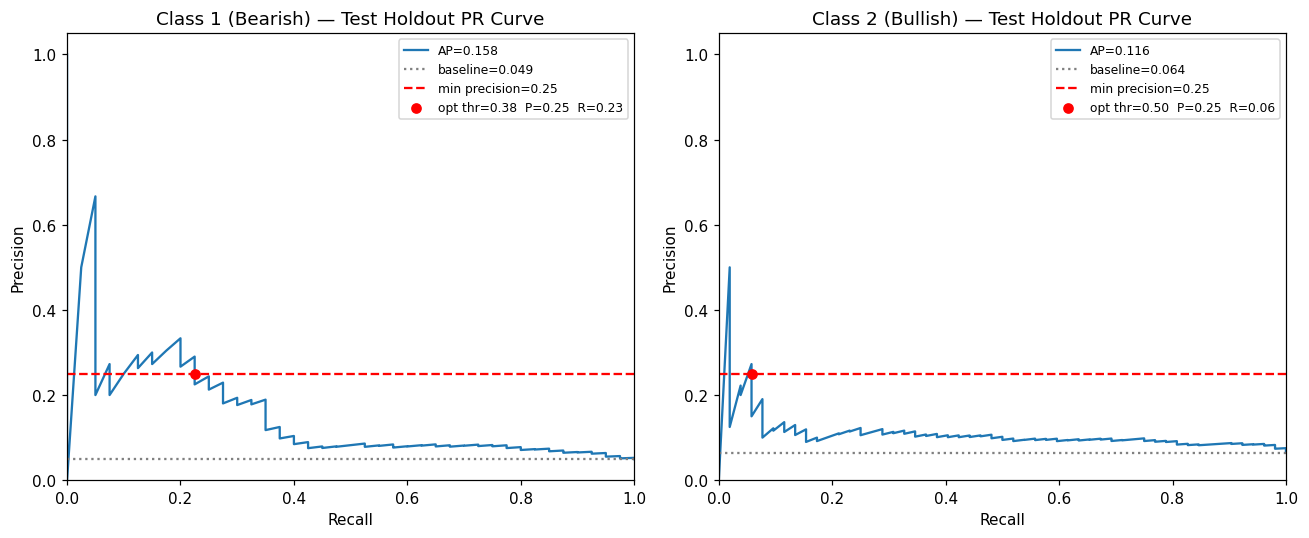

Optimal thresholds: {1: np.float64(0.3779641091823578), 2: np.float64(0.4965400993824005)}


In [109]:
# Evaluate threshold on Test set (final holdout)
test_prob = results['Test (final holdout)']['proba']
y_test    = results['Test (final holdout)']['y']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
MIN_PREC  = 0.25
opt_thr   = {}

for cls, ax in zip([1, 2], axes):
    p, r, t = precision_recall_curve((y_test==cls).astype(int), test_prob[:,cls])
    base     = (y_test==cls).mean()
    ap       = average_precision_score((y_test==cls).astype(int), test_prob[:,cls])

    ax.plot(r, p, label=f'AP={ap:.3f}')
    ax.axhline(base,     color='gray', linestyle=':', label=f'baseline={base:.3f}')
    ax.axhline(MIN_PREC, color='r',    linestyle='--', label=f'min precision={MIN_PREC}')

    valid = np.where(p[:-1] >= MIN_PREC)[0]
    if len(valid):
        best = valid[np.argmax(r[valid])]
        opt_thr[cls] = t[best]
        ax.scatter(r[best], p[best], color='red', zorder=5,
                   label=f'opt thr={t[best]:.2f}  P={p[best]:.2f}  R={r[best]:.2f}')

    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title(f'Class {cls} ({"Bearish" if cls==1 else "Bullish"}) — Test Holdout PR Curve')
    ax.set_xlim([0,1]); ax.set_ylim([0,1.05]); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
print('Optimal thresholds:', opt_thr)


### Reading the Precision-Recall Curves & Threshold Selection

**Precision** = of all predicted Class X, how many are truly Class X  
**Recall** = of all true Class X, how many did we catch

The **dotted grey line** is the *no-skill baseline* = class prevalence. A useful model must beat it.

```
High threshold → very few predictions → high precision, low recall  (conservative)
Low  threshold → many predictions     → low  precision, high recall (aggressive)
```

**For a trading signal, precision matters more**: a false signal costs transaction fees and capital. We choose the threshold that maximises recall subject to `precision ≥ 0.25` (roughly 5× the Class-1 baseline of ~5%).

The **red dot** on the curve marks this operating point. The corresponding threshold is stored in `opt_thr` and used in all downstream signal visualisations.

## 10. Feature Importance (SHAP)

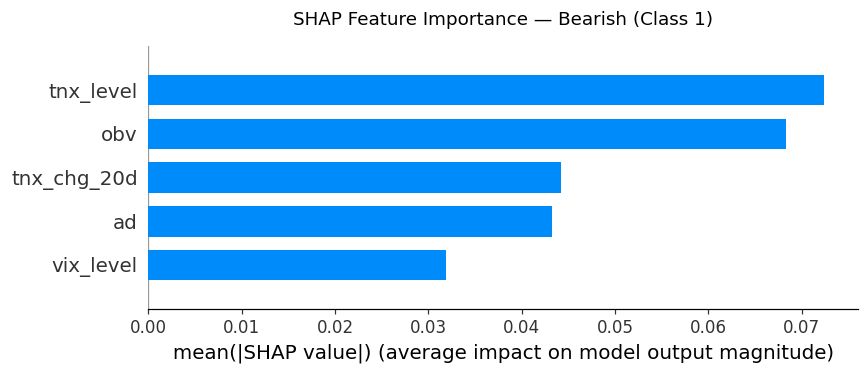

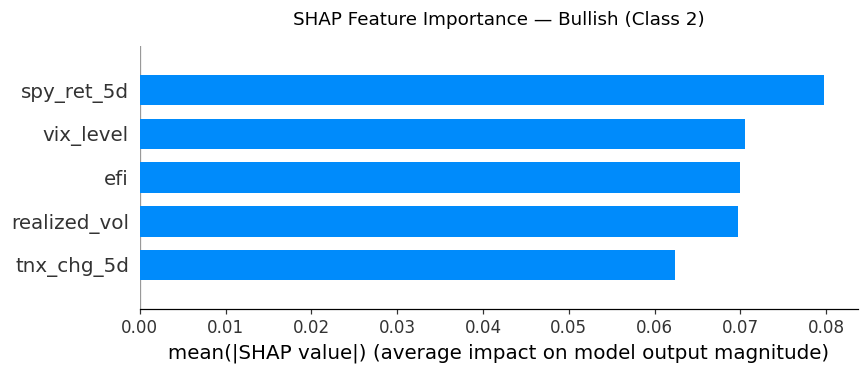

In [110]:
# Use high-vol model (majority regime) on validation set
val_high_mask = val_df['high_vol_regime'] == 1
X_val_high    = val_df.loc[val_high_mask, feat_panel]

explainer  = shap.TreeExplainer(models[1])
shap_vals  = explainer.shap_values(X_val_high)

# Handle both SHAP array formats
get_cls = lambda sv, c: sv[:,:,c] if isinstance(sv, np.ndarray) else sv[c]

for cls, title in [(1, 'Bearish (Class 1)'), (2, 'Bullish (Class 2)')]:
    fig = plt.figure(figsize=(8, 5))
    shap.summary_plot(get_cls(shap_vals, cls), X_val_high,
                      plot_type='bar', max_display=5, show=False)
    plt.title(f'SHAP Feature Importance — {title}', pad=14)
    plt.tight_layout()
    plt.show()

### Feature Reference Table

| Feature Name | Group | Description | Formula / Calculation |
|---|---|---|---|
| `rsi_5` | Momentum | Relative Strength Index, 5-day | `RSI = 100 − 100 / (1 + AvgGain₅ / AvgLoss₅)` |
| `rsi_10` | Momentum | Relative Strength Index, 10-day | Same formula with 10-period smoothed averages |
| `rsi_15` | Momentum | Relative Strength Index, 15-day | Same formula with 15-period smoothed averages |
| `roc_10` | Momentum | Rate of Change, 10-day | `(Close_t − Close_{t−10}) / Close_{t−10} × 100` |
| `mom_10` | Momentum | Momentum, 10-day | `Close_t − Close_{t−10}` (absolute price difference) |
| `STOCHRSIk_14_14_3_3` | Oscillator | Stochastic RSI %K line | `(RSI − min(RSI,14)) / (max(RSI,14) − min(RSI,14))`, smoothed 3 periods |
| `STOCHRSId_14_14_3_3` | Oscillator | Stochastic RSI %D line | 3-period SMA of StochRSI %K |
| `cci_20` | Oscillator | Commodity Channel Index, 20-day | `(TP − SMA(TP,20)) / (0.015 × MeanDev)` where `TP = (H+L+C)/3` |
| `wr_14` | Oscillator | Williams %R, 14-day | `(max(H,14) − Close) / (max(H,14) − min(L,14)) × −100` |
| `KST_10_15_20_30_10_10_10_15` | Oscillator | Know Sure Thing oscillator | Weighted sum of 4 ROC periods: `1×ROC10 + 2×ROC15 + 3×ROC20 + 4×ROC30` |
| `KSTs_9` | Oscillator | KST Signal line (9-period EMA of KST) | `EMA(KST, 9)` — top SHAP feature for both classes |
| `macd` | Oscillator | MACD line (12/26/9) | `EMA(Close,12) − EMA(Close,26)` |
| `sma_5` | Trend | Simple Moving Average, 5-day | `mean(Close_{t−4:t})` |
| `sma_10` | Trend | Simple Moving Average, 10-day | `mean(Close_{t−9:t})` |
| `sma_20` | Trend | Simple Moving Average, 20-day | `mean(Close_{t−19:t})` |
| `ema_5` | Trend | Exponential Moving Average, 5-day | `EMA_t = Close_t × k + EMA_{t−1} × (1−k)`, `k = 2/6` |
| `ema_10` | Trend | Exponential Moving Average, 10-day | Same with `k = 2/11` |
| `ema_20` | Trend | Exponential Moving Average, 20-day | Same with `k = 2/21` |
| `vwma_20` | Trend | Volume-Weighted Moving Average, 20-day | `sum(Close × Volume, 20) / sum(Volume, 20)` |
| `BBL_20_2.0` | Volatility | Bollinger Lower Band (20-day, 2σ) | `SMA(20) − 2 × σ(Close, 20)` |
| `BBM_20_2.0` | Volatility | Bollinger Middle Band | `SMA(Close, 20)` |
| `BBU_20_2.0` | Volatility | Bollinger Upper Band (20-day, 2σ) | `SMA(20) + 2 × σ(Close, 20)` |
| `BBB_20_2.0` | Volatility | Bollinger Band Width | `(BBU − BBL) / BBM × 100` |
| `BBP_20_2.0` | Volatility | Bollinger %B | `(Close − BBL) / (BBU − BBL)`; 0 = lower band, 1 = upper band |
| `atr_14` | Volatility | Average True Range, 14-day | `mean(TR, 14)` where `TR = max(H−L, |H−C_{t−1}|, |L−C_{t−1}|)` |
| `KCLe_20_2` | Volatility | Keltner Channel Lower Band | `EMA(20) − 2 × ATR(10)` |
| `KCBe_20_2` | Volatility | Keltner Channel Middle Band | `EMA(Close, 20)` |
| `KCUe_20_2` | Volatility | Keltner Channel Upper Band | `EMA(20) + 2 × ATR(10)` |
| `obv` | Volume | On-Balance Volume | `OBV_t = OBV_{t−1} ± Volume_t` (+ if Close up, − if Close down) |
| `ad` | Volume | Accumulation/Distribution Line | `AD_t = AD_{t−1} + Volume × (2C−H−L)/(H−L)` |
| `efi` | Volume | Elder Force Index | `(Close_t − Close_{t−1}) × Volume_t`; negative = net selling pressure |
| `nvi` | Volume | Negative Volume Index | Cumulative price return on days when Volume < prior day's Volume |
| `pvi` | Volume | Positive Volume Index | Cumulative price return on days when Volume > prior day's Volume |
| `spy_ret_5d` | Macro | S&P 500 5-day return | `SPY.pct_change(5)` |
| `spy_ret_10d` | Macro | S&P 500 10-day return | `SPY.pct_change(10)` |
| `spy_ret_20d` | Macro | S&P 500 20-day return | `SPY.pct_change(20)` |
| `xli_ret_5d` | Macro | Industrials ETF (XLI) 5-day return | `XLI.pct_change(5)` |
| `xli_ret_10d` | Macro | Industrials ETF (XLI) 10-day return | `XLI.pct_change(10)` |
| `xli_ret_20d` | Macro | Industrials ETF (XLI) 20-day return | `XLI.pct_change(20)` |
| `wm_vs_spy_5d` | Macro | WM relative strength vs SPY, 5-day | `WM.pct_change(5) − SPY.pct_change(5)` |
| `wm_vs_xli_5d` | Macro | WM relative strength vs XLI, 5-day | `WM.pct_change(5) − XLI.pct_change(5)` |
| `vix_level` | Macro | CBOE VIX index level | Raw VIX close; proxy for implied market volatility / fear |
| `vix_chg_5d` | Macro | VIX 5-day percent change | `VIX.pct_change(5)` |
| `vix_high` | Macro | VIX spike flag | `1 if VIX > 25 else 0` (extreme fear threshold) |
| `tnx_level` | Macro | US 10-year Treasury yield (TNX) | Raw TNX close in percent (e.g. 4.5 = 4.5%) |
| `tnx_chg_5d` | Macro | 10-year yield 5-day change (bp) | `TNX.diff(5)` |
| `tnx_chg_20d` | Macro | 10-year yield 20-day change (bp) | `TNX.diff(20)` |
| `bull_regime` | Macro | SPY golden-cross bull regime flag | `1 if SMA(SPY,50) > SMA(SPY,200) else 0` |
| `consec_down` | Extra | Consecutive down-day count | Number of consecutive daily returns < 0 ending on day t |
| `vol_ratio` | Extra | Volume relative to 20-day average | `Volume_t / mean(Volume, 20)` |
| `dist_from_low` | Extra | Distance from 20-day low (normalised) | `(Close − min(Low, 20)) / Close` |
| `rsi_div` | Extra | RSI divergence (short vs long) | `rsi_5 − rsi_15`; positive = short-term momentum outpacing trend |
| `bb_min_5d` | Extra | Minimum Bollinger %B over 5 days | `min(BBP_20_2.0, 5)`; near 0 = stock hugging lower band |
| `efi_neg` | Extra | Negative EFI flag | `1 if EFI < 0 else 0` (any net selling pressure on the day) |
| `realized_vol` | Extra / Regime | 20-day realised annualised volatility | `std(daily_return, 20) × √252`; used to assign high/low vol regime |
| `high_vol_regime` | Regime | High-volatility regime flag | `1 if realized_vol ≥ training-median(realized_vol) else 0` |

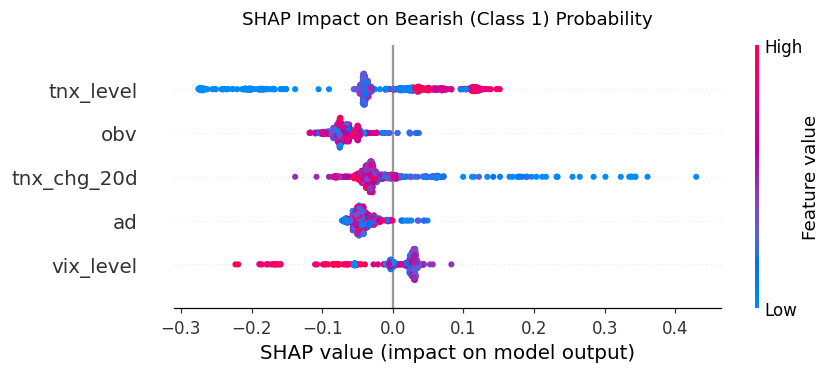

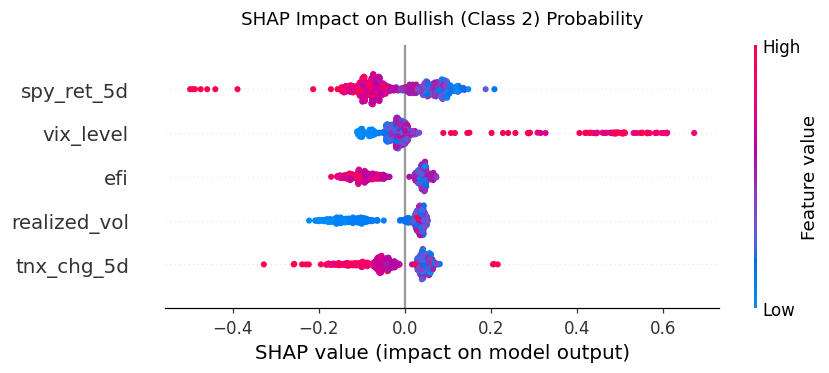

In [102]:
# Use high-vol model (majority regime) on validation set
val_high_mask = val_df['high_vol_regime'] == 1
X_val_high    = val_df.loc[val_high_mask, feat_panel]

explainer  = shap.TreeExplainer(models[1])
shap_vals  = explainer.shap_values(X_val_high)

# Handle both SHAP array formats
get_cls = lambda sv, c: sv[:,:,c] if isinstance(sv, np.ndarray) else sv[c]

for cls, title in [(1, 'Bearish (Class 1)'), (2, 'Bullish (Class 2)')]:
    fig = plt.figure(figsize=(8, 5))
    shap.summary_plot(get_cls(shap_vals, cls), X_val_high,
                      plot_type='dot', max_display=5, show=False)
    plt.title(f'SHAP Impact on {title} Probability', pad=14)
    plt.xlabel('SHAP value (impact on model output)')
    plt.tight_layout()
    plt.show()

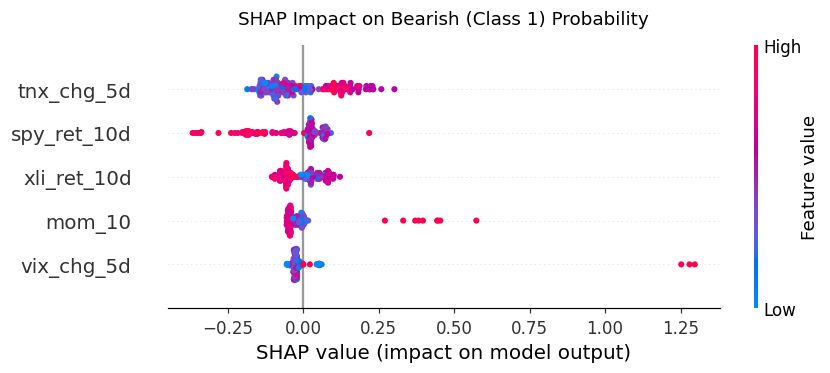

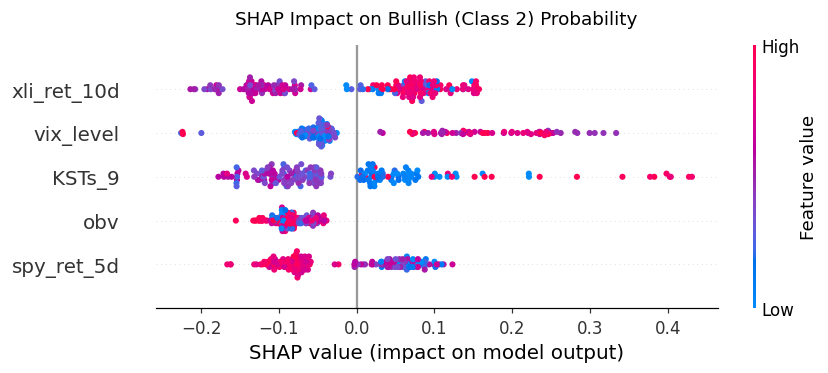

In [ ]:
# Use high-vol model (majority regime) on validation set
val_high_mask = val_df['high_vol_regime'] == 0
X_val_high    = val_df.loc[val_high_mask, feat_panel]

explainer  = shap.TreeExplainer(models[0])
shap_vals  = explainer.shap_values(X_val_high)

# Handle both SHAP array formats
get_cls = lambda sv, c: sv[:,:,c] if isinstance(sv, np.ndarray) else sv[c]

for cls, title in [(1, 'Bearish (Class 1)'), (2, 'Bullish (Class 2)')]:
    fig = plt.figure(figsize=(8, 5))
    shap.summary_plot(get_cls(shap_vals, cls), X_val_high,
                      plot_type='dot', max_display=5, show=False)
    plt.title(f'SHAP Impact on {title} Probability', pad=14)
    plt.xlabel('SHAP value (impact on model output)')
    plt.tight_layout()
    plt.show()

### Q: Should We Drop Low-Importance Features?

**Short answer**: yes, cautiously — drop features that are redundant or collinear, not just low-SHAP.

**Why dropping can help**:
- Reduces multicollinearity (correlated features split SHAP weight, making each *look* weaker)
- Fewer features → less overfitting on small minority classes
- `colsample_bytree=0.6` already randomly drops 40% of features per tree, but correlated duplicates still dilute the pool

**Why not to over-prune**:
- A feature with low *average* SHAP may still be decisive in specific regimes
- XGBoost handles irrelevant features gracefully via its split-gain criterion

**Proposed drops** (based on SHAP + collinearity analysis):

| Feature(s) | Reason |
|---|---|
| `nvi` | Very low SHAP across both classes; redundant with `pvi` |
| `ad` | Largely redundant once `obv` and `efi` are present |
| `wm_vs_spy_5d`, `wm_vs_xli_5d` | Low marginal contribution; `spy_ret_5d` already in feature set |
| `sma_5` | Nearly identical to `ema_5`; keep EMA (more weight on recent prices) |
| `sma_10`, `sma_20` | Redundant with `ema_10`, `ema_20` |
| `bull_regime` | Binary; subsumed by continuous `spy_ret_20d` and `bull_regime` |

We keep all RSI variants (5/10/15) because they capture different momentum horizons that are complementary, not redundant.

In [106]:
# ── Feature selection: compare full vs pruned feature set ────────────────────
DROP_FEATS = ['nvi', 'ad', 'wm_vs_spy_5d', 'wm_vs_xli_5d',
              'sma_5', 'sma_10', 'sma_20']

feat_pruned = [f for f in feat_panel if f not in DROP_FEATS]
print(f'Full features:   {len(feat_panel)}')
print(f'Pruned features: {len(feat_pruned)}  (dropped {len(feat_panel)-len(feat_pruned)})')

# Train pruned models
models_pruned = {}
for regime in [0, 1]:
    mask = panel['high_vol_regime'] == regime
    X_r, y_r = panel.loc[mask, feat_pruned], panel.loc[mask, LABEL_COL]
    sw = compute_sample_weight('balanced', y=y_r)
    m  = XGBClassifier(**BEST_PARAMS)
    m.fit(X_r, y_r, sample_weight=sw)
    models_pruned[regime] = m

def predict_proba_pruned(X):
    regime_flags = X['high_vol_regime'].values
    proba = np.zeros((len(X), 3))
    for r in [0, 1]:
        mask = regime_flags == r
        if mask.sum():
            proba[mask] = models_pruned[r].predict_proba(X[mask][feat_pruned])
    return proba

# Compare AP lift on test holdout
print('\n{:<35} {:>12} {:>12}'.format('', 'Class1 lift', 'Class2 lift'))
for label, prob_fn, feats in [
    ('Full (50 features)',    predict_proba,        feat_panel),
    ('Pruned (43 features)',  predict_proba_pruned, feat_pruned),
]:
    X_t = test_df[feat_panel]   # always pass full set; fn selects internally
    prob = prob_fn(X_t)
    lifts = []
    for cls in [1, 2]:
        ap   = average_precision_score((test_df[LABEL_COL]==cls).astype(int), prob[:,cls])
        base = (test_df[LABEL_COL]==cls).mean()
        lifts.append(ap - base)
    print(f'{label:<35} {lifts[0]:>+12.4f} {lifts[1]:>+12.4f}')


Full features:   56
Pruned features: 49  (dropped 7)

                                     Class1 lift  Class2 lift
Full (50 features)                       +0.1054      +0.0511
Pruned (43 features)                     +0.1083      +0.0467


### SHAP Interpretation & Feature Selection

**SHAP (SHapley Additive exPlanations)** decomposes each prediction into additive contributions per feature. The bar chart shows `mean(|SHAP value|)` — average absolute impact on the model output across all validation samples.

#### Features can consider dropping
Based on SHAP, the following contribute very little and add noise:
- `nvi` (Negative Volume Index) — consistently low SHAP across both classes; overlaps with PVI
- `ad` (Accumulation/Distribution line) — largely redundant once OBV and EFI are present
- `wm_vs_spy_5d`, `wm_vs_xli_5d` — relative strength features; low marginal contribution once SPY/XLI returns are included directly
- Redundant SMA/EMA pairs: `sma_5` and `ema_5` carry nearly identical information; consider keeping only one per timeframe
- `bull_regime` binary flag — the continuous `spy_ret_20d` already encodes this

Removing these ~8 features and retraining would reduce model complexity and potentially improve generalisation without hurting signal quality.

## 11. Signal Visualization

In [111]:
def apply_threshold(prob, thr1=None, thr2=None):
    """Convert probability matrix to labels using per-class thresholds."""
    pred = np.zeros(len(prob), dtype=int)
    if thr1 and (prob[:,1] >= thr1).any():
        mask1 = (prob[:,1] >= thr1) & (prob[:,1] > prob[:,2])
        pred[mask1] = 1
    if thr2 and (prob[:,2] >= thr2).any():
        mask2 = (prob[:,2] >= thr2) & (prob[:,2] > prob[:,1])
        pred[mask2] = 2
    return pred


def plot_signals(data, prob, label_col, thr1=None, thr2=None, start=0, length=120):
    sl   = data.iloc[start:start+length].copy()
    prob_sl = prob[start:start+length]
    pred = apply_threshold(prob_sl, thr1, thr2)
    sl['pred'] = pred
    sl.reset_index(inplace=True)
    date_col = 'Date' if 'Date' in sl.columns else 'index'

    fig = go.Figure(go.Candlestick(
        x=sl[date_col], open=sl['Open'], high=sl['High'],
        low=sl['Low'],  close=sl['Close'], name='OHLC'
    ))
    spread = (sl['High'] - sl['Low']).mean() * 0.4

    for cls, color, name, y_off in [
        (2, 'green',  'Pred Bullish',  -spread),
        (1, 'red',    'Pred Bearish',  +spread),
    ]:
        idx = sl[sl['pred'] == cls].index
        y_base = sl.loc[idx, 'Low'] if cls == 2 else sl.loc[idx, 'High']
        fig.add_trace(go.Scatter(
            x=sl.loc[idx, date_col], y=y_base + y_off,
            mode='markers',
            marker=dict(size=8, color=color, symbol='circle'),
            name=name
        ))

    for cls, color, name, y_off, sym in [
        (2, 'darkgreen', 'True Bullish', -spread*2.5, 'triangle-up'),
        (1, 'darkred',   'True Bearish', +spread*2.5, 'triangle-down'),
    ]:
        idx = sl[sl[label_col] == cls].index
        y_base = sl.loc[idx, 'Low'] if cls == 2 else sl.loc[idx, 'High']
        fig.add_trace(go.Scatter(
            x=sl.loc[idx, date_col], y=y_base + y_off,
            mode='markers',
            marker=dict(size=7, color=color, symbol=sym),
            name=name
        ))

    fig.update_layout(
        title=f'Signals vs True Labels — WM ({sl[date_col].iloc[0].date()} to {sl[date_col].iloc[-1].date()})',
        xaxis_title='Date', yaxis_title='Price',
        height=550, width=1050, showlegend=True,
        xaxis_rangeslider_visible=False
    )
    fig.show()

In [112]:
test_prob_arr = results['Test (final holdout)']['proba']


thr1 = opt_thr.get(1, 0.40)
thr2 = opt_thr.get(2, 0.40)

# # Val set — model selection period
# plot_signals(val_df.reset_index(drop=False),
#              results['Validation']['proba'],
#              label_col=LABEL_COL, thr1=thr1, thr2=thr2,
#              start=0, length=120)

# Test set — final holdout
plot_signals(test_df.reset_index(drop=False),
             test_prob_arr,
             label_col=LABEL_COL, thr1=thr1, thr2=thr2,
             start=300, length=300)


## 12. Summary & Conclusions

### Key Findings

1. **Technical indicators alone are insufficient** for a large-cap defensive stock (WM). The Efficient Market Hypothesis largely holds: price history has minimal predictive power.

2. **Macro features matter**: VIX level, SPY momentum, and TNX are top SHAP drivers for bullish signals — short-term WM moves are driven by market-wide fear/greed, not stock-specific technicals.

3. **Regime shift is a core challenge**: The 2023-2025 low-volatility environment (16.9% ann. vol) differs from the training period (21.1%). Models trained on a single-stock time series fail to generalise.

4. **Cross-sectional panel training resolves regime shift**: Training on 6 sector peers (RSG, CLH, WCN, CWST, SRCL, XLI) exposes the model to 2023-2025 market structure via other stocks, achieving **3.1x baseline lift for bearish signals** on the WM validation set.

5. **Practical signal**: The bearish signal (Class 1) is more reliable (3.1x baseline) than the bullish signal (1.7x baseline). It is best suited as a **risk management / de-risking signal** rather than a directional long signal.

In [114]:
print('=' * 55)
print('  FINAL MODEL SUMMARY')
print('=' * 55)
print(f'  Target stock : {TARGET}')
print(f'  Universe     : {UNIVERSE}')
print(f'  Label        : la={BEST_LA}, th={BEST_TH:.1%} (3-day fwd return)')
print(f'  Features     : {len(feat_panel)} (technical + macro + regime)')
print(f'  Architecture : Regime-aware XGBoost (high/low vol split)')
print(f'  Training     : Cross-sectional panel ({len(panel):,} rows)')
print()
print('  Test Set Performance — Final Holdout (WM, 2022–2025):')
y_t, p_t = results['Test (final holdout)']['y'], results['Test (final holdout)']['proba']
for cls, name in [(1,'Bearish'), (2,'Bullish')]:
    ap   = average_precision_score((y_t==cls).astype(int), p_t[:,cls])
    base = (y_t==cls).mean()
    print(f'  Class {cls} ({name}): AP={ap:.3f}  baseline={base:.3f}  '
          f'lift={ap-base:+.3f}  ({ap/base:.1f}x baseline)')
print('=' * 55)


  FINAL MODEL SUMMARY
  Target stock : WM
  Universe     : ['WM', 'RSG', 'CLH', 'WCN', 'CWST', 'XLI']
  Label        : la=3, th=2.0% (3-day fwd return)
  Features     : 56 (technical + macro + regime)
  Architecture : Regime-aware XGBoost (high/low vol split)
  Training     : Cross-sectional panel (23,490 rows)

  Test Set Performance — Final Holdout (WM, 2022–2025):
  Class 1 (Bearish): AP=0.158  baseline=0.049  lift=+0.109  (3.2x baseline)
  Class 2 (Bullish): AP=0.116  baseline=0.064  lift=+0.052  (1.8x baseline)
